Model training

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import pickle

In [3]:
df = pd.read_csv("cleaned_health_data.csv")
df.head()

,Diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
#feature selection
selected_features = ['BMI','Smoker','HvyAlcoholConsump','Stroke','PhysHlth','MentHlth','DiffWalk','Sex','Age','PhysActivity','GenHlth']

X = df[selected_features]
y = df['Diabetes']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (229781, 11)
Target Shape: (229781,)


In [6]:
#train test data split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (183824, 11)
Testing Shape: (45957, 11)


In [7]:
#feature scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature Scaling Completed")

Feature Scaling Completed


In [8]:
#logistic regression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


In [9]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", lr_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.829797419326762

Classification Report:

              precision    recall  f1-score   support

         0.0       0.84      0.98      0.91     38116
         1.0       0.00      0.00      0.00       906
         2.0       0.49      0.12      0.19      6935

    accuracy                           0.83     45957
   macro avg       0.44      0.37      0.37     45957
weighted avg       0.77      0.83      0.78     45957



c:\Users\narai\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\narai\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\narai\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

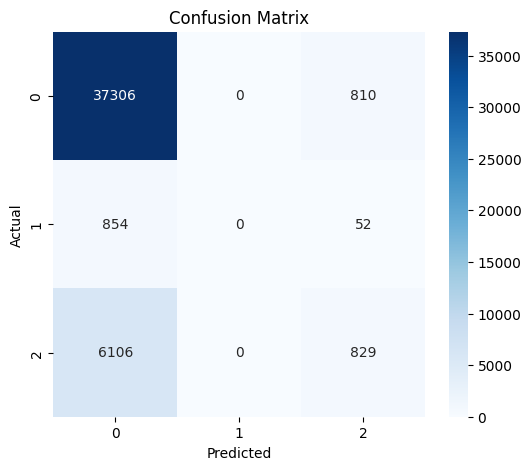

In [10]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
#random forest

rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [12]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", rf_accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8122157669125487

Classification Report:

              precision    recall  f1-score   support

         0.0       0.85      0.94      0.89     38116
         1.0       0.03      0.00      0.01       906
         2.0       0.39      0.20      0.26      6935

    accuracy                           0.81     45957
   macro avg       0.42      0.38      0.39     45957
weighted avg       0.76      0.81      0.78     45957



In [13]:
print("Logistic Regression Accuracy :", lr_accuracy)
print("Random Forest Accuracy :", rf_accuracy)

Logistic Regression Accuracy : 0.829797419326762
Random Forest Accuracy : 0.8122157669125487


In [14]:
pickle.dump(rf_model, open("health_model.pkl", "wb"))
print("Model Saved Successfully")

Model Saved Successfully


In [15]:
pickle.dump(scaler, open("scaler.pkl", "wb"))
print("Scaler Saved Successfully")

Scaler Saved Successfully
